# Wie hat sich die staatliche Finanzierung je Schüler an Oberschulen in freier Trägerschaft entwickelt?

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

df_finanzierung = pd.read_csv(
    "../data/cleaned/schuelerausgabensaetze_oberschule.csv",
    sep=";"
)

display(df_finanzierung)
df_finanzierung.info()

,schuljahr,schuelerausgabensatz_eur
0,2018/19,6027.27
1,2019/20,6431.76
2,2020/21,6591.08
3,2021/22,6698.22
4,2022/23,7058.01
5,2023/24,7324.17
6,2024/25,7421.35
7,2025/26,7642.69


<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   schuljahr                 8 non-null      str    
 1   schuelerausgabensatz_eur  8 non-null      float64
dtypes: float64(1), str(1)
memory usage: 260.0 bytes


Gesamtentwicklung berechnen:

In [44]:
startwert = df_finanzierung.loc[
    df_finanzierung["schuljahr"] == "2018/19",
    "schuelerausgabensatz_eur"
].iloc[0]

endwert = df_finanzierung.loc[
    df_finanzierung["schuljahr"] == "2025/26",
    "schuelerausgabensatz_eur"
].iloc[0]

veraenderung_absolut = endwert - startwert
veraenderung_prozent = (endwert / startwert - 1) * 100

print(f"2018/19: {startwert:.2f} €")
print(f"2025/26: {endwert:.2f} €")
print(f"Veränderung absolut: {veraenderung_absolut:.2f} €")
print(f"Veränderung prozentual: {veraenderung_prozent:.1f} %")

2018/19: 6027.27 €
2025/26: 7642.69 €
Veränderung absolut: 1615.42 €
Veränderung prozentual: 26.8 %


Jährliche Veränderungsraten berechnen:

In [45]:
df_finanzierung["veraenderung_prozent"] = (
    df_finanzierung["schuelerausgabensatz_eur"]
    .pct_change() # berechnet die prozentuale Veränderung im Vergleich zum vorherigen Schuljahr
    .mul(100) # multipliziert die prozentuale Veränderung mit 100, um sie in Prozent auszudrücken
)

df_finanzierung.round(2)

,schuljahr,schuelerausgabensatz_eur,veraenderung_prozent
0,2018/19,6027.27,NaN
1,2019/20,6431.76,6.71
2,2020/21,6591.08,2.48
3,2021/22,6698.22,1.63
4,2022/23,7058.01,5.37
5,2023/24,7324.17,3.77
6,2024/25,7421.35,1.33
7,2025/26,7642.69,2.98


Die jährlichen Steigerungen reichen von +1,33 % bis +6,71 %. Sie sind immer nur gestiegen.

In [46]:
jahr_max = df_finanzierung.loc[
    df_finanzierung["veraenderung_prozent"].idxmax()
]

jahr_min = df_finanzierung.loc[
    df_finanzierung["veraenderung_prozent"].idxmin()
]

print(
    f"Stärkster Anstieg: {jahr_max['schuljahr']} "
    f"mit {jahr_max['veraenderung_prozent']:.2f} %"
)

print(
    f"Schwächster Anstieg: {jahr_min['schuljahr']} "
    f"mit {jahr_min['veraenderung_prozent']:.2f} %"
)

Stärkster Anstieg: 2019/20 mit 6.71 %
Schwächster Anstieg: 2024/25 mit 1.33 %


Erste Visualisierung (Liniendiagramm)

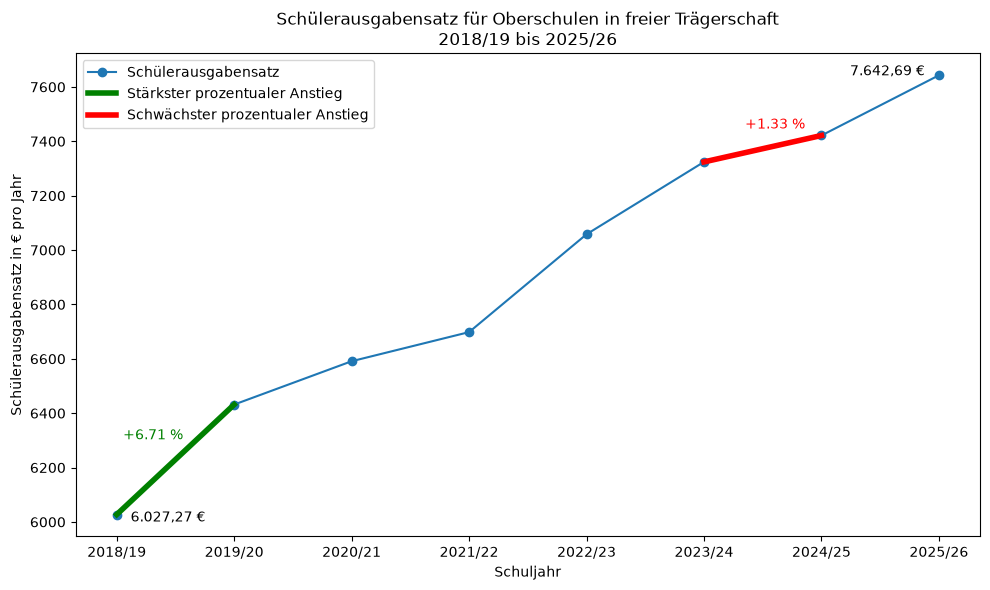

In [47]:
def format_euro(wert):
    return (
        f"{wert:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
        + " €"
    )


fig, ax = plt.subplots(figsize=(10, 6))

# Gesamte Zeitreihe
ax.plot(
    df_finanzierung["schuljahr"],
    df_finanzierung["schuelerausgabensatz_eur"],
    marker="o",
    label="Schülerausgabensatz",
)

# Positionen des stärksten und schwächsten Anstiegs
idx_max = df_finanzierung["veraenderung_prozent"].idxmax()
idx_min = df_finanzierung["veraenderung_prozent"].idxmin()

# Stärkster Anstieg: Verbindung zum jeweiligen Vorjahr hervorheben
ax.plot(
    df_finanzierung.loc[idx_max - 1:idx_max, "schuljahr"],
    df_finanzierung.loc[idx_max - 1:idx_max, "schuelerausgabensatz_eur"],
    linewidth=4,
    color="green",
    label="Stärkster prozentualer Anstieg",
)

# Schwächster Anstieg
ax.plot(
    df_finanzierung.loc[idx_min - 1:idx_min, "schuljahr"],
    df_finanzierung.loc[idx_min - 1:idx_min, "schuelerausgabensatz_eur"],
    linewidth=4,
    color="red",
    label="Schwächster prozentualer Anstieg",
)

# Anfangs- und Endwert
start = df_finanzierung.iloc[0]
ende = df_finanzierung.iloc[-1]

ax.annotate(
    format_euro(start["schuelerausgabensatz_eur"]),
    xy=(0, start["schuelerausgabensatz_eur"]),
    xytext=(10, -5),
    textcoords="offset points",
)

ax.annotate(
    format_euro(ende["schuelerausgabensatz_eur"]),
    xy=(len(df_finanzierung) - 1, ende["schuelerausgabensatz_eur"]),
    xytext=(-10, 0),
    textcoords="offset points",
    ha="right",
)

# Veränderungsraten an den hervorgehobenen Abschnitten
ax.annotate(
    f"+{df_finanzierung.loc[idx_max, 'veraenderung_prozent']:.2f} %",
    xy=(
        idx_max,
        df_finanzierung.loc[idx_max, "schuelerausgabensatz_eur"],
    ),
    xytext=(-80, -25),
    textcoords="offset points",
    color="green",
)

ax.annotate(
    f"+{df_finanzierung.loc[idx_min, 'veraenderung_prozent']:.2f} %",
    xy=(
        idx_min,
        df_finanzierung.loc[idx_min, "schuelerausgabensatz_eur"],
    ),
    xytext=(-55, 5),
    textcoords="offset points",
    color="red",
)

ax.set_title(
    "Schülerausgabensatz für Oberschulen in freier Trägerschaft\n"
    "2018/19 bis 2025/26"
)
ax.set_xlabel("Schuljahr")
ax.set_ylabel("Schülerausgabensatz in € pro Jahr")
ax.legend()

# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Entwicklung des Schülerausgabensatzes

**Beobachtung:** Der Schülerausgabensatz für Oberschulen in freier Trägerschaft stieg im gesamten betrachteten Zeitraum von 6.027,27 € je Schüler im Schuljahr 2018/19 auf 7.642,69 € im Schuljahr 2025/26. Dies entspricht einem nominalen Anstieg um 1.615,42 € bzw. 26,8 %.

In jedem betrachteten Schuljahr lag der Schülerausgabensatz über dem Wert des Vorjahres. Die jährlichen prozentualen Steigerungen fielen jedoch unterschiedlich stark aus. Der stärkste Anstieg erfolgte von 2018/19 auf 2019/20 mit 6,71 %, der schwächste von 2023/24 auf 2024/25 mit 1,33 %.

**Interpretation:** Die Daten zeigen einen kontinuierlichen nominalen Anstieg der staatlichen Finanzierung je Schüler an Oberschulen in freier Trägerschaft. Aus der nominalen Entwicklung allein lässt sich jedoch nicht ableiten, in welchem Umfang damit auch die reale Finanzierung bzw. Kaufkraft gestiegen ist. Dafür müsste zusätzlich die allgemeine Preisentwicklung berücksichtigt werden.

## Zusatzanalyse: Inflationsbereinigung mit dem allgemeinen Verbraucherpreisindex (VPI) für Deutschland von Destatis

Für jedes Schuljahr wird näherungsweise ein VPI aus den beiden beteiligten Kalenderjahren gebildet:

Für das Schuljahr 2018/19 gilt beispielsweise:

$$
VPI_{2018/19} = \frac{VPI_{2018} + VPI_{2019}}{2}
$$

Damit ergibt sich:

$$
VPI_{2018/19} = \frac{98{,}1 + 99{,}5}{2} = 98{,}8
$$

In [48]:
vpi = pd.DataFrame({
    "jahr": [
        2018, 2019, 2020, 2021,
        2022, 2023, 2024, 2025
    ],
    "vpi": [
        98.1, 99.5, 100.0, 103.1,
        110.2, 116.7, 119.3, 121.9
    ]
})

vpi

# Diese Werte stammen aus der Destatis-Tabelle „Verbraucherpreisindex: Deutschland, 
# Jahre“ (61111-0001), Basis 2020 = 100.

,jahr,vpi
0,2018,98.1
1,2019,99.5
2,2020,100.0
3,2021,103.1
4,2022,110.2
5,2023,116.7
6,2024,119.3
7,2025,121.9


Problem bei dieser Methode: Für das Schuljahr 2025/26 würde man auch den Jahresdurchschnitt 2026 benötigen. Der existiert im August 2026 aber noch nicht vollständig.

### VPI-Jahreswerten für die Werte für die Schuljahre berechnen

In [52]:
vpi_schuljahr = pd.DataFrame({
    "schuljahr": [
        "2018/19",
        "2019/20",
        "2020/21",
        "2021/22",
        "2022/23",
        "2023/24",
        "2024/25",
    ],
    "vpi_schuljahr": (
        vpi["vpi"].iloc[:-1].to_numpy()
        + vpi["vpi"].iloc[1:].to_numpy()
    ) / 2,
})

vpi_schuljahr

,schuljahr,vpi_schuljahr
0,2018/19,98.80
1,2019/20,99.75
2,2020/21,101.55
3,2021/22,106.65
4,2022/23,113.45
5,2023/24,118.00
6,2024/25,120.60


In [53]:
df_finanzierung_real = df_finanzierung.merge(
    vpi_schuljahr,
    on="schuljahr",
    how="inner",
)

df_finanzierung_real

,schuljahr,schuelerausgabensatz_eur,veraenderung_prozent,vpi_schuljahr
0,2018/19,6027.27,NaN,98.80
1,2019/20,6431.76,6.710999,99.75
2,2020/21,6591.08,2.477082,101.55
3,2021/22,6698.22,1.625530,106.65
4,2022/23,7058.01,5.371427,113.45
5,2023/24,7324.17,3.771035,118.00
6,2024/25,7421.35,1.326840,120.60


### Inflationsbereinigte Entwicklung

Für die Inflationsbereinigung wird das Schuljahr 2018/19 als Preisbasis verwendet.

$$
\text{Realer Schülerausgabensatz}_t
=
\text{Nominaler Schülerausgabensatz}_t
\times
\frac{VPI_{2018/19}}{VPI_t}
$$

In [54]:
vpi_basis = df_finanzierung_real.loc[
    df_finanzierung_real["schuljahr"] == "2018/19",
    "vpi_schuljahr"
].iloc[0]

df_finanzierung_real["schuelerausgabensatz_real_eur"] = (
    df_finanzierung_real["schuelerausgabensatz_eur"]
    * vpi_basis
    / df_finanzierung_real["vpi_schuljahr"]
)

df_finanzierung_real.round(2)

,schuljahr,schuelerausgabensatz_eur,veraenderung_prozent,vpi_schuljahr,schuelerausgabensatz_real_eur
0,2018/19,6027.27,NaN,98.80,6027.27
1,2019/20,6431.76,6.71,99.75,6370.51
2,2020/21,6591.08,2.48,101.55,6412.59
3,2021/22,6698.22,1.63,106.65,6205.20
4,2022/23,7058.01,5.37,113.45,6146.60
5,2023/24,7324.17,3.77,118.00,6132.44
6,2024/25,7421.35,1.33,120.60,6079.85


### Reale Gesamtveränderung

In [55]:
start = df_finanzierung_real.iloc[0]
ende = df_finanzierung_real.iloc[-1]

vergleich_nominal_real = pd.DataFrame({
    "2018/19": [
        start["schuelerausgabensatz_eur"],
        start["schuelerausgabensatz_real_eur"],
    ],
    "2024/25": [
        ende["schuelerausgabensatz_eur"],
        ende["schuelerausgabensatz_real_eur"],
    ],
}, index=["Nominal", "Real (Preise 2018/19)"])

vergleich_nominal_real["Veränderung absolut"] = (
    vergleich_nominal_real["2024/25"]
    - vergleich_nominal_real["2018/19"]
)

vergleich_nominal_real["Veränderung Prozent"] = (
    (
        vergleich_nominal_real["2024/25"]
        / vergleich_nominal_real["2018/19"]
        - 1
    )
    * 100
)

vergleich_nominal_real.round(2)

,2018/19,2024/25,Veränderung absolut,Veränderung Prozent
Nominal,6027.27,7421.35,1394.08,23.13
Real (Preise 2018/19),6027.27,6079.85,52.58,0.87


Unter Verwendung des allgemeinen Verbraucherpreisindex und der gewählten Schuljahres-Näherung ergibt sich für 2018/19 bis 2024/25 ein realer Anstieg des Schülerausgabensatzes von **nur** rund 0,9 %.

### Jährliche reale Veränderungsrate

In [56]:
df_finanzierung_real["veraenderung_real_prozent"] = (
    df_finanzierung_real["schuelerausgabensatz_real_eur"]
    .pct_change()
    .mul(100)
)

df_finanzierung_real[
    [
        "schuljahr",
        "schuelerausgabensatz_eur",
        "veraenderung_prozent",
        "schuelerausgabensatz_real_eur",
        "veraenderung_real_prozent",
    ]
].round(2)

,schuljahr,schuelerausgabensatz_eur,veraenderung_prozent,schuelerausgabensatz_real_eur,veraenderung_real_prozent
0,2018/19,6027.27,NaN,6027.27,NaN
1,2019/20,6431.76,6.71,6370.51,5.69
2,2020/21,6591.08,2.48,6412.59,0.66
3,2021/22,6698.22,1.63,6205.20,-3.23
4,2022/23,7058.01,5.37,6146.60,-0.94
5,2023/24,7324.17,3.77,6132.44,-0.23
6,2024/25,7421.35,1.33,6079.85,-0.86


## Nominale und reale Entwicklung visualisieren:

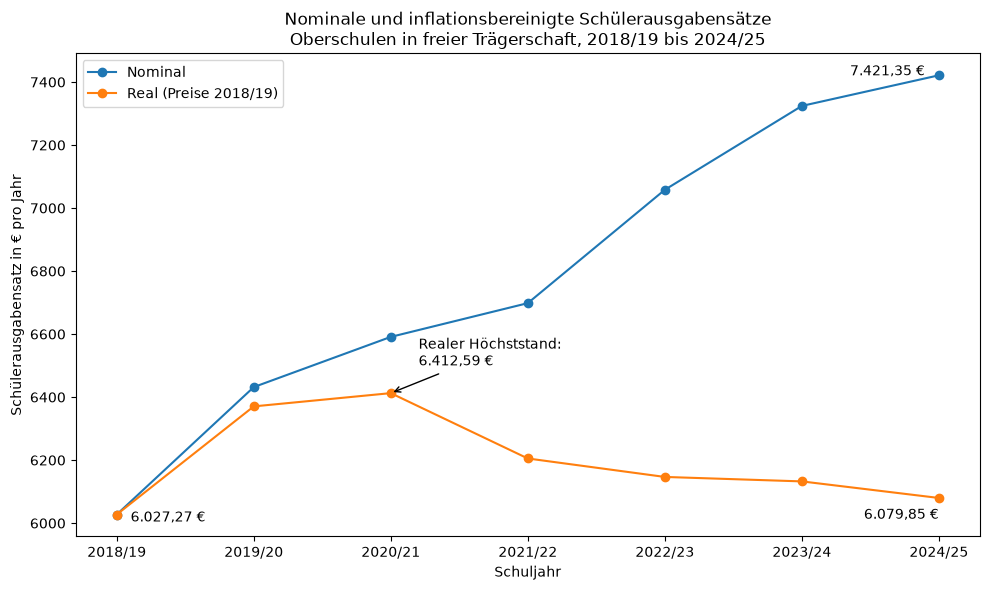

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    df_finanzierung_real["schuljahr"],
    df_finanzierung_real["schuelerausgabensatz_eur"],
    marker="o",
    label="Nominal",
)

ax.plot(
    df_finanzierung_real["schuljahr"],
    df_finanzierung_real["schuelerausgabensatz_real_eur"],
    marker="o",
    label="Real (Preise 2018/19)",
)

ax.set_title(
    "Nominale und inflationsbereinigte Schülerausgabensätze\n"
    "Oberschulen in freier Trägerschaft, 2018/19 bis 2024/25"
)
ax.set_xlabel("Schuljahr")
ax.set_ylabel("Schülerausgabensatz in € pro Jahr")
ax.legend()

# Gemeinsamer Ausgangswert
ax.annotate(
    format_euro(df_finanzierung_real.loc[0, "schuelerausgabensatz_eur"]),
    xy=(0, df_finanzierung_real.loc[0, "schuelerausgabensatz_eur"]),
    xytext=(10, -5),
    textcoords="offset points",
)

# Realer Höchststand
idx_real_max = df_finanzierung_real[
    "schuelerausgabensatz_real_eur"
].idxmax()

ax.annotate(
    f"Realer Höchststand:\n"
    f"{format_euro(df_finanzierung_real.loc[idx_real_max, 'schuelerausgabensatz_real_eur'])}",
    xy=(
        idx_real_max,
        df_finanzierung_real.loc[
            idx_real_max, "schuelerausgabensatz_real_eur"
        ],
    ),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
)

# Endwerte 2024/25
ax.annotate(
    format_euro(df_finanzierung_real.iloc[-1]["schuelerausgabensatz_eur"]),
    xy=(
        len(df_finanzierung_real) - 1,
        df_finanzierung_real.iloc[-1]["schuelerausgabensatz_eur"],
    ),
    xytext=(-10, 0),
    textcoords="offset points",
    ha="right",
)

ax.annotate(
    format_euro(
        df_finanzierung_real.iloc[-1]["schuelerausgabensatz_real_eur"]
    ),
    xy=(
        len(df_finanzierung_real) - 1,
        df_finanzierung_real.iloc[-1]["schuelerausgabensatz_real_eur"],
    ),
    xytext=(0, -15),
    textcoords="offset points",
    ha="right",
)

# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Inflationsbereinigte Entwicklung

**Beobachtung:** Nominal stieg der Schülerausgabensatz zwischen 2018/19 und 2024/25 von 6.027,27 € auf 7.421,35 € je Schüler. Dies entspricht einem Anstieg um 1.394,08 € bzw. 23,13 %.

Nach der Inflationsbereinigung auf das Preisniveau von 2018/19 ergibt sich für 2024/25 dagegen ein Schülerausgabensatz von 6.079,85 €. Gegenüber 2018/19 entspricht dies einem realen Anstieg um 52,58 € bzw. 0,87 %.

Der inflationsbereinigte Schülerausgabensatz erreichte 2020/21 mit 6.412,59 € seinen höchsten Wert. Seit 2021/22 war die jährliche reale Veränderungsrate in jedem betrachteten Schuljahr negativ. Der nominale Schülerausgabensatz stieg dagegen in jedem Jahr.

**Interpretation:** Unter den Annahmen der verwendeten Inflationsbereinigung wurde der nominale Anstieg des Schülerausgabensatzes zwischen 2018/19 und 2024/25 weitgehend durch die allgemeine Preisentwicklung aufgezehrt. Die reale Finanzierung je Schüler lag 2024/25 nach dieser Modellrechnung nur geringfügig über dem Ausgangsniveau von 2018/19.

**Methodische Einschränkungen:** Die inflationsbereinigten Werte sind keine amtlich veröffentlichten realen Schülerausgabensätze, sondern eine eigene Modellrechnung. Als Deflator wird der allgemeine Verbraucherpreisindex (VPI) für Deutschland verwendet. Dieser bildet die allgemeine Preisentwicklung der privaten Konsumausgaben ab und nicht speziell die Kostenstruktur von Schulen.

Da die Finanzierungsdaten nach Schuljahren und die verwendeten VPI-Werte nach Kalenderjahren vorliegen, wurde der VPI eines Schuljahres näherungsweise als arithmetischer Mittelwert der beiden beteiligten Kalenderjahre berechnet. Die reale Entwicklung wird deshalb nur für 2018/19 bis 2024/25 ausgewiesen. Für 2025/26 fehlt bei dieser Methode noch der vollständige VPI-Jahreswert 2026.